In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0f0',
    'xtick.color':      '#9a9ab0',
    'ytick.color':      '#9a9ab0',
    'text.color':       '#e0e0f0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

ACCENT  = '#7c83fd'
ACCENT2 = '#f97316'
ACCENT3 = '#34d399'
ACCENT4 = '#f472b6'
print('Style configured.')

Using device: cpu
Style configured.


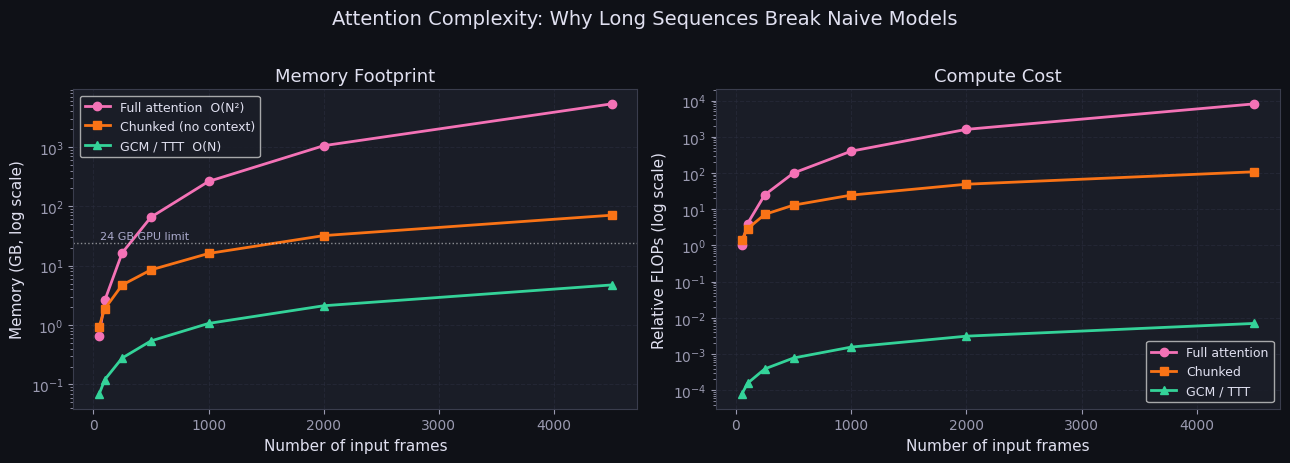

In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 1 — Complexity: why long sequences break naive models
# ─────────────────────────────────────────────────────────────

N_frames   = np.array([50, 100, 250, 500, 1000, 2000, 4500])
tokens_per = 256
bytes_per  = 4
d          = 1024

N_tok     = N_frames * tokens_per
mem_full  = (N_tok ** 2) * bytes_per / 1e9

chunk_size = 60 * tokens_per
n_chunks   = np.ceil(N_frames / 60)
mem_chunk  = n_chunks * (chunk_size ** 2) * bytes_per / 1e9

H       = 4e6
mem_ttt = (N_tok * d + H) * bytes_per / 1e9

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Attention Complexity: Why Long Sequences Break Naive Models',
             fontsize=14, y=1.02)

ax = axes[0]
ax.semilogy(N_frames, mem_full,  'o-', color=ACCENT4, lw=2, label='Full attention  O(N²)')
ax.semilogy(N_frames, mem_chunk, 's-', color=ACCENT2, lw=2, label='Chunked (no context)')
ax.semilogy(N_frames, mem_ttt,   '^-', color=ACCENT3, lw=2, label='GCM / TTT  O(N)')
ax.axhline(24, color='#ffffff', lw=1, ls=':', alpha=0.5)
ax.text(60, 28, '24 GB GPU limit', fontsize=8, color='#aaaacc')
ax.set_xlabel('Number of input frames')
ax.set_ylabel('Memory (GB, log scale)')
ax.set_title('Memory Footprint')
ax.legend(fontsize=9)
ax.grid(True)

ax = axes[1]
flops_full  = N_tok ** 2
flops_chunk = n_chunks * chunk_size ** 2
flops_ttt   = N_tok
base = flops_full[0]
ax.semilogy(N_frames, flops_full  / base, 'o-', color=ACCENT4, lw=2, label='Full attention')
ax.semilogy(N_frames, flops_chunk / base, 's-', color=ACCENT2, lw=2, label='Chunked')
ax.semilogy(N_frames, flops_ttt   / base, '^-', color=ACCENT3, lw=2, label='GCM / TTT')
ax.set_xlabel('Number of input frames')
ax.set_ylabel('Relative FLOPs (log scale)')
ax.set_title('Compute Cost')
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.show()

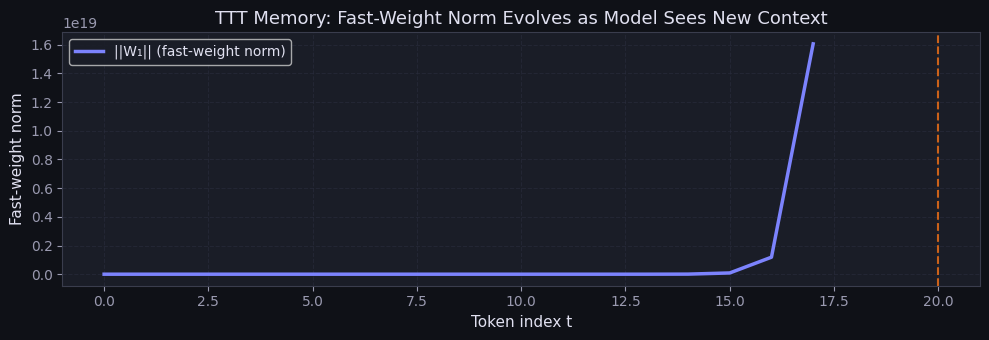

Output shape: torch.Size([2, 40, 64])  ✓


In [6]:
# ─────────────────────────────────────────────────────────────
# SECTION 2 — TTT as memory 
# ─────────────────────────────────────────────────────────────

class MinimalTTTLayer(nn.Module):
    def __init__(self, dim: int, hidden_mul: int = 4, inner_lr: float = 0.01):
        super().__init__()
        self.dim      = dim
        self.inner_lr = inner_lr
        self.proj_qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.proj_out  = nn.Linear(dim, dim,     bias=False)
        h = dim * hidden_mul
        self.W1_init = torch.randn(dim, h) * 0.02
        self.W2_init = torch.randn(h, dim) * 0.02

    def forward(self, x: torch.Tensor):
        B, T, D = x.shape
        with torch.no_grad():
            qkv = self.proj_qkv(x)
        Q, K, V = qkv.chunk(3, dim=-1)

        W1 = self.W1_init.clone()
        W2 = self.W2_init.clone()

        outputs      = []
        weight_norms = []

        for t in range(T):
            k_t = K[:, t].detach()
            v_t = V[:, t].detach()
            q_t = Q[:, t].detach()

            # Fresh leaf tensors every iteration — no stale graph
            W1_leaf = W1.detach().requires_grad_(True)
            W2_leaf = W2.detach().requires_grad_(True)

            pred = F.silu(k_t @ W1_leaf) @ W2_leaf
            loss = -(pred * v_t).sum()
            loss.backward()

            with torch.no_grad():
                W1 = W1_leaf - self.inner_lr * W1_leaf.grad
                W2 = W2_leaf - self.inner_lr * W2_leaf.grad

            with torch.no_grad():
                o_t = F.silu(q_t @ W1) @ W2

            outputs.append(o_t)
            weight_norms.append(W1.norm().item())

        out = torch.stack(outputs, dim=1)
        with torch.no_grad():
            out = self.proj_out(out)
        return out, weight_norms


D, T, B = 64, 40, 2
ttt = MinimalTTTLayer(dim=D, inner_lr=0.05)

x = torch.randn(B, T, D)
x[:, :20] += torch.randn(1, 1, D) * 2

out, weight_norms = ttt(x)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(weight_norms, color=ACCENT, lw=2.5, label='||W₁|| (fast-weight norm)')
ax.axvline(20, color=ACCENT2, lw=1.5, ls='--', alpha=0.8)
ax.text(21, max(weight_norms) * 0.95, 'Pattern shift', color=ACCENT2, fontsize=9)
ax.set_xlabel('Token index t')
ax.set_ylabel('Fast-weight norm')
ax.set_title('TTT Memory: Fast-Weight Norm Evolves as Model Sees New Context')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
print(f'Output shape: {out.shape}  ✓')

In [7]:
# ─────────────────────────────────────────────────────────────
# SECTION 3 — Global Context Memory (GCM) module
# ─────────────────────────────────────────────────────────────

class AdaptiveMemoryUnit(nn.Module):
    def __init__(self, head_dim: int, scale: int = 4):
        super().__init__()
        h = head_dim * scale
        self.register_buffer('W1', torch.randn(head_dim, h) * 0.02)
        self.register_buffer('W2', torch.randn(h, head_dim) * 0.02)
        self.register_buffer('W3', torch.randn(head_dim, h) * 0.02)

    def forward(self, x):
        return (F.silu(x @ self.W1) * (x @ self.W3)) @ self.W2

    def state_size(self):
        return self.W1.numel() + self.W2.numel() + self.W3.numel()


class GlobalContextMemory(nn.Module):
    def __init__(self, dim: int, n_heads: int = 1, scale: int = 4,
                 inner_lr: float = 1e-3):
        super().__init__()
        assert dim % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = dim // n_heads
        self.inner_lr = inner_lr

        self.proj_qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.proj_out  = nn.Linear(dim, dim,     bias=False)
        self.gate      = nn.Parameter(torch.zeros(dim))
        self.amus      = nn.ModuleList([
            AdaptiveMemoryUnit(self.head_dim, scale) for _ in range(n_heads)
        ])

    def _update_amu(self, amu, K, V):
        """Manual gradient update — avoids double-backward issues."""
        W1 = amu.W1.clone().requires_grad_(True)
        W2 = amu.W2.clone().requires_grad_(True)
        W3 = amu.W3.clone().requires_grad_(True)

        pred = (F.silu(K @ W1) * (K @ W3)) @ W2
        loss = -(pred * V).sum()
        loss.backward()

        with torch.no_grad():
            amu.W1.copy_(W1 - self.inner_lr * W1.grad)
            amu.W2.copy_(W2 - self.inner_lr * W2.grad)
            amu.W3.copy_(W3 - self.inner_lr * W3.grad)

    def forward(self, X: torch.Tensor):
        M, D = X.shape
        qkv  = self.proj_qkv(X)
        Q, K, V = qkv.chunk(3, dim=-1)

        Q = Q.view(M, self.n_heads, self.head_dim)
        K = K.view(M, self.n_heads, self.head_dim)
        V = V.view(M, self.n_heads, self.head_dim)

        head_outs = []
        for h, amu in enumerate(self.amus):
            self._update_amu(amu, K[:, h], V[:, h])
            with torch.no_grad():
                o_h = amu(Q[:, h])
            head_outs.append(o_h)

        gcm_out = torch.cat(head_outs, dim=-1)
        gcm_out = self.proj_out(gcm_out)
        alpha   = torch.sigmoid(self.gate)
        return alpha * gcm_out + X

    def total_state_size(self):
        return sum(a.state_size() for a in self.amus)


# Verify state sizes
print(f'{"dim":>6}  {"actual state size":>20}')
print('-' * 30)
for dim in [64, 128, 256, 1024]:
    gcm = GlobalContextMemory(dim=dim, n_heads=1, scale=4)
    print(f'{dim:>6}  {gcm.total_state_size():>20,}')

   dim     actual state size
------------------------------
    64                49,152
   128               196,608
   256               786,432
  1024            12,582,912


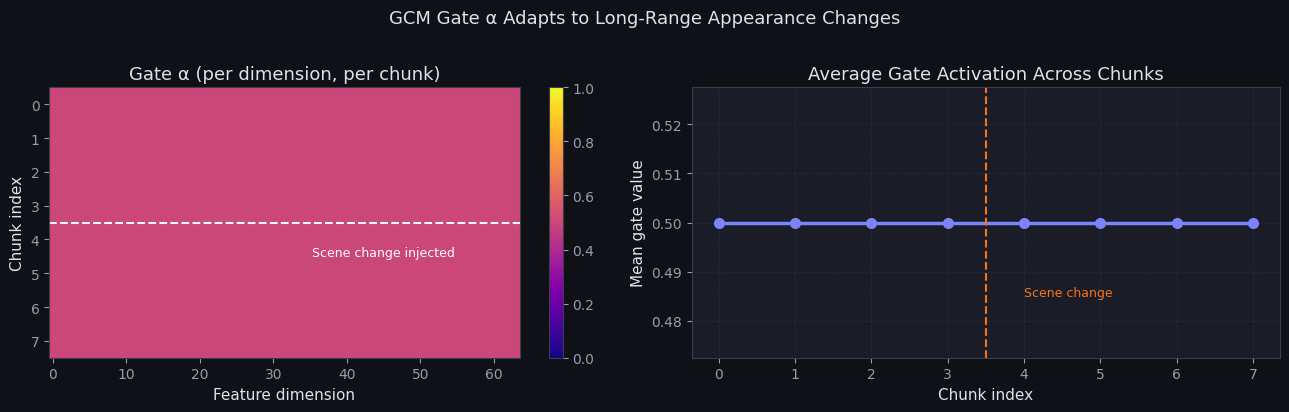

In [9]:
# ─────────────────────────────────────────────────────────────
# SECTION 4 — Gate activation over chunks
# ─────────────────────────────────────────────────────────────
class AdaptiveMemoryUnit(nn.Module):
    def __init__(self, head_dim: int, scale: int = 4):
        super().__init__()
        h = head_dim * scale
        # Plain tensors, not Parameters — we update them manually
        self.W1 = torch.randn(head_dim, h) * 0.02
        self.W2 = torch.randn(h, head_dim) * 0.02
        self.W3 = torch.randn(head_dim, h) * 0.02

    def forward(self, x):
        return (F.silu(x @ self.W1) * (x @ self.W3)) @ self.W2

    def state_size(self):
        return self.W1.numel() + self.W2.numel() + self.W3.numel()


class GlobalContextMemory(nn.Module):
    def __init__(self, dim: int, n_heads: int = 1, scale: int = 4,
                 inner_lr: float = 1e-3):
        super().__init__()
        assert dim % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = dim // n_heads
        self.inner_lr = inner_lr

        self.proj_qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.proj_out  = nn.Linear(dim, dim,     bias=False)
        self.gate      = nn.Parameter(torch.zeros(dim))
        self.amus      = nn.ModuleList([
            AdaptiveMemoryUnit(self.head_dim, scale) for _ in range(n_heads)
        ])

    def _update_amu(self, amu, K, V):
        # Fresh leaf tensors every call — same fix as Section 2
        W1 = amu.W1.detach().requires_grad_(True)
        W2 = amu.W2.detach().requires_grad_(True)
        W3 = amu.W3.detach().requires_grad_(True)

        pred = (F.silu(K.detach() @ W1) * (K.detach() @ W3)) @ W2
        loss = -(pred * V.detach()).sum()
        loss.backward()

        with torch.no_grad():
            amu.W1 = W1 - self.inner_lr * W1.grad
            amu.W2 = W2 - self.inner_lr * W2.grad
            amu.W3 = W3 - self.inner_lr * W3.grad

    def forward(self, X: torch.Tensor):
        M, D = X.shape
        with torch.no_grad():
            qkv = self.proj_qkv(X)
        Q, K, V = qkv.chunk(3, dim=-1)

        Q = Q.view(M, self.n_heads, self.head_dim)
        K = K.view(M, self.n_heads, self.head_dim)
        V = V.view(M, self.n_heads, self.head_dim)

        head_outs = []
        for h, amu in enumerate(self.amus):
            self._update_amu(amu, K[:, h], V[:, h])   # update weights
            with torch.no_grad():
                o_h = amu(Q[:, h])                     # apply updated weights
            head_outs.append(o_h)

        with torch.no_grad():
            gcm_out = torch.cat(head_outs, dim=-1)
            gcm_out = self.proj_out(gcm_out)
            alpha   = torch.sigmoid(self.gate)
        return alpha * gcm_out + X

    def total_state_size(self):
        return sum(a.state_size() for a in self.amus)


# ── Now run Section 4 ──────────────────────────────────────────────────────
dim         = 64
gcm         = GlobalContextMemory(dim=dim, n_heads=1, scale=4, inner_lr=5e-3)
n_chunks    = 8
chunk_size  = 30
gate_traces = []

for c in range(n_chunks):
    X = torch.randn(chunk_size, dim)
    if c > 3:
        X[:, :dim // 4] += 3.0
    _ = gcm(X)   # no torch.no_grad() here — _update_amu needs to backward internally
    gate_traces.append(torch.sigmoid(gcm.gate).detach().numpy().copy())

gate_traces = np.array(gate_traces)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(gate_traces, aspect='auto', cmap='plasma',
                    vmin=0, vmax=1, interpolation='nearest')
axes[0].axhline(3.5, color='white', lw=1.5, ls='--')
axes[0].text(dim * 0.55, 4.5, 'Scene change injected', color='white', fontsize=9)
axes[0].set_xlabel('Feature dimension')
axes[0].set_ylabel('Chunk index')
axes[0].set_title('Gate α (per dimension, per chunk)')
plt.colorbar(im, ax=axes[0])

axes[1].plot(gate_traces.mean(axis=1), 'o-', color=ACCENT, lw=2.5, ms=7)
axes[1].axvline(3.5, color=ACCENT2, lw=1.5, ls='--')
axes[1].text(4.0, gate_traces.mean(axis=1).max() * 0.97,
             'Scene change', color=ACCENT2, fontsize=9)
axes[1].set_xlabel('Chunk index')
axes[1].set_ylabel('Mean gate value')
axes[1].set_title('Average Gate Activation Across Chunks')
axes[1].grid(True)

plt.suptitle('GCM Gate α Adapts to Long-Range Appearance Changes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

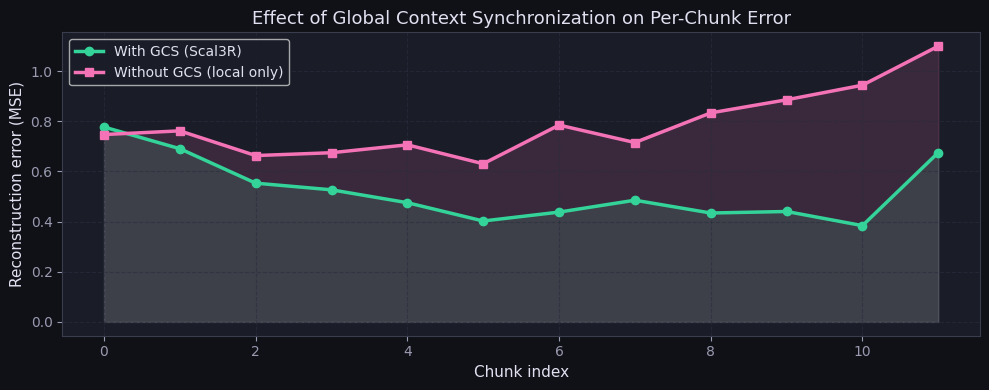

In [10]:
# ─────────────────────────────────────────────────────────────
# SECTION 5 — Global Context Synchronization simulation
# ─────────────────────────────────────────────────────────────

def simulate_gcs(n_chunks=12, chunk_size=20, dim=32, use_gcs=True):
    W    = torch.zeros(dim, dim)
    errs = []

    for c in range(n_chunks):
        angle = c * (math.pi / n_chunks)
        R     = torch.tensor([
            [math.cos(angle), -math.sin(angle)],
            [math.sin(angle),  math.cos(angle)]
        ])

        K = torch.randn(chunk_size, dim)
        V = K.clone()
        V[:, :2] = V[:, :2] @ R

        W_local = W.clone().requires_grad_(True)
        pred    = F.silu(K @ W_local)
        loss    = -(pred * V[:, :pred.shape[-1]]).sum()
        loss.backward()

        with torch.no_grad():
            delta = 0.01 * W_local.grad
            if use_gcs:
                W = W - delta
            else:
                W = W_local.detach() - delta
                W = W + 0.05 * torch.randn_like(W)   # drift without sync

        with torch.no_grad():
            pred = F.silu(K @ W)
            err  = (pred - V[:, :pred.shape[-1]]).pow(2).mean().item()
        errs.append(err)

    return errs


errs_gcs   = simulate_gcs(use_gcs=True)
errs_nogcs = simulate_gcs(use_gcs=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(errs_gcs,   'o-', color=ACCENT3, lw=2.5, ms=6, label='With GCS (Scal3R)')
ax.plot(errs_nogcs, 's-', color=ACCENT4, lw=2.5, ms=6, label='Without GCS (local only)')
ax.fill_between(range(len(errs_gcs)),   errs_gcs,   alpha=0.15, color=ACCENT3)
ax.fill_between(range(len(errs_nogcs)), errs_nogcs, alpha=0.15, color=ACCENT4)
ax.set_xlabel('Chunk index')
ax.set_ylabel('Reconstruction error (MSE)')
ax.set_title('Effect of Global Context Synchronization on Per-Chunk Error')
ax.legend(fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()

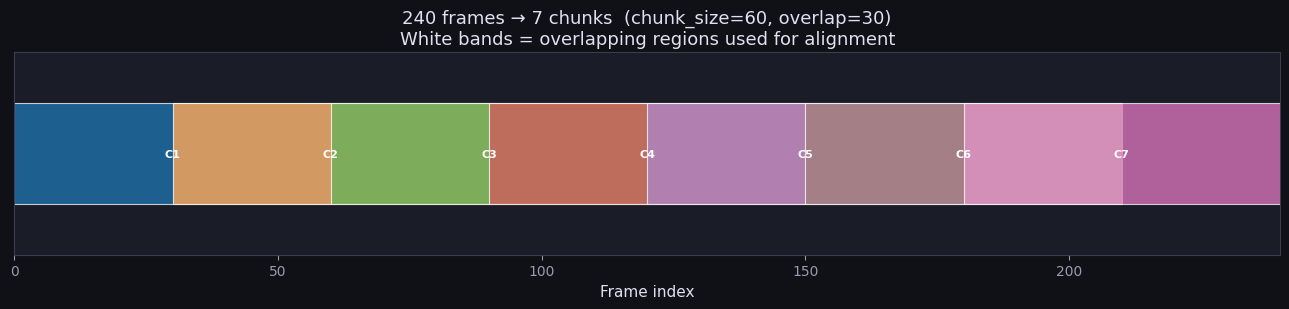

Total chunks:   7
Avg chunk size: 60.0 frames


In [11]:
# ─────────────────────────────────────────────────────────────
# SECTION 6 — Chunking pipeline visualisation
# ─────────────────────────────────────────────────────────────

def make_chunks(N, chunk_size, overlap):
    stride = chunk_size - overlap
    chunks, start = [], 0
    while start < N:
        end = min(start + chunk_size, N)
        chunks.append((start, end))
        if end == N:
            break
        start += stride
    return chunks


N_frames   = 240
chunk_size = 60
overlap    = 30
chunks     = make_chunks(N_frames, chunk_size, overlap)

fig, ax = plt.subplots(figsize=(13, 3.2))
cmap = plt.cm.get_cmap('tab10')

for i, (s, e) in enumerate(chunks):
    color = cmap(i % 10)
    ax.barh(0, e - s, left=s, height=0.5, color=color,
            alpha=0.75, edgecolor='white', linewidth=0.8)
    ax.text((s + e) / 2, 0, f'C{i+1}', ha='center', va='center',
            fontsize=8, color='white', fontweight='bold')

for i, (s, e) in enumerate(chunks[:-1]):
    next_s = chunks[i + 1][0]
    ax.barh(0, e - next_s, left=next_s, height=0.5,
            color='white', alpha=0.25, linewidth=0)

ax.set_xlim(0, N_frames)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel('Frame index')
ax.set_yticks([])
ax.set_title(
    f'{N_frames} frames → {len(chunks)} chunks  '
    f'(chunk_size={chunk_size}, overlap={overlap})\n'
    'White bands = overlapping regions used for alignment'
)
plt.tight_layout()
plt.show()

print(f'Total chunks:   {len(chunks)}')
print(f'Avg chunk size: {np.mean([e-s for s,e in chunks]):.1f} frames')

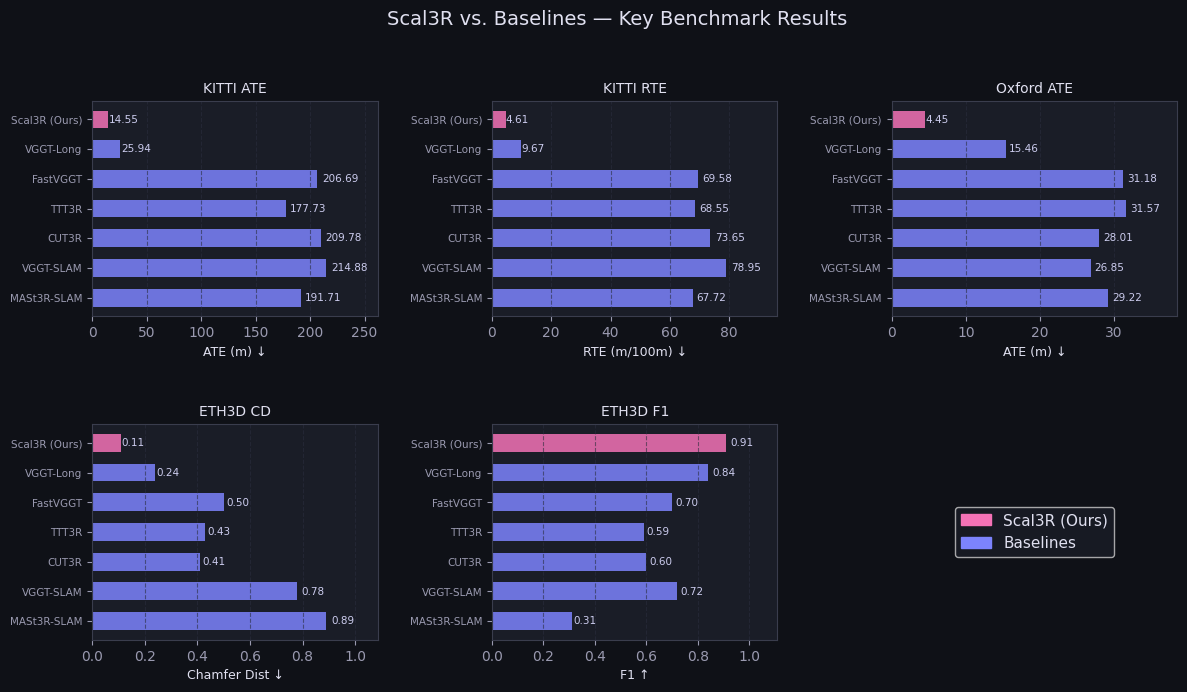

In [12]:
# ─────────────────────────────────────────────────────────────
# SECTION 7 — Benchmark results (Table 1 & 2 from paper)
# ─────────────────────────────────────────────────────────────

results = {
    'Method':     ['MASt3R-SLAM', 'VGGT-SLAM', 'CUT3R', 'TTT3R',
                   'FastVGGT', 'VGGT-Long', 'Scal3R (Ours)'],
    'KITTI ATE':  [191.71, 214.88, 209.78, 177.73, 206.69, 25.94, 14.55],
    'KITTI RTE':  [67.72,  78.95,  73.65,  68.55,  69.58,  9.67,  4.61],
    'Oxford ATE': [29.22,  26.85,  28.01,  31.57,  31.18, 15.46,  4.45],
    'ETH3D CD':   [0.89,   0.78,   0.41,   0.43,   0.50,   0.24,  0.11],
    'ETH3D F1':   [0.31,   0.72,   0.60,   0.59,   0.70,   0.84,  0.91],
}

methods = results['Method']
colors  = [ACCENT4 if 'Ours' in m else ACCENT for m in methods]

fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.4)

metrics = [
    ('KITTI ATE',  'ATE (m) ↓',      gs[0, 0]),
    ('KITTI RTE',  'RTE (m/100m) ↓', gs[0, 1]),
    ('Oxford ATE', 'ATE (m) ↓',      gs[0, 2]),
    ('ETH3D CD',   'Chamfer Dist ↓', gs[1, 0]),
    ('ETH3D F1',   'F1 ↑',           gs[1, 1]),
]

for key, ylabel, spec in metrics:
    ax   = fig.add_subplot(spec)
    vals = results[key]
    bars = ax.barh(methods, vals, color=colors, height=0.6, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=7.5, color='#ccccee')
    ax.set_xlabel(ylabel, fontsize=9)
    ax.set_title(key, fontsize=10)
    ax.set_xlim(0, max(vals) * 1.22)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.grid(True, axis='x')

ax_leg = fig.add_subplot(gs[1, 2])
ax_leg.axis('off')
ax_leg.legend(handles=[
    mpatches.Patch(color=ACCENT4, label='Scal3R (Ours)'),
    mpatches.Patch(color=ACCENT,  label='Baselines'),
], fontsize=11, loc='center')

fig.suptitle('Scal3R vs. Baselines — Key Benchmark Results', fontsize=14, y=1.01)
plt.show()

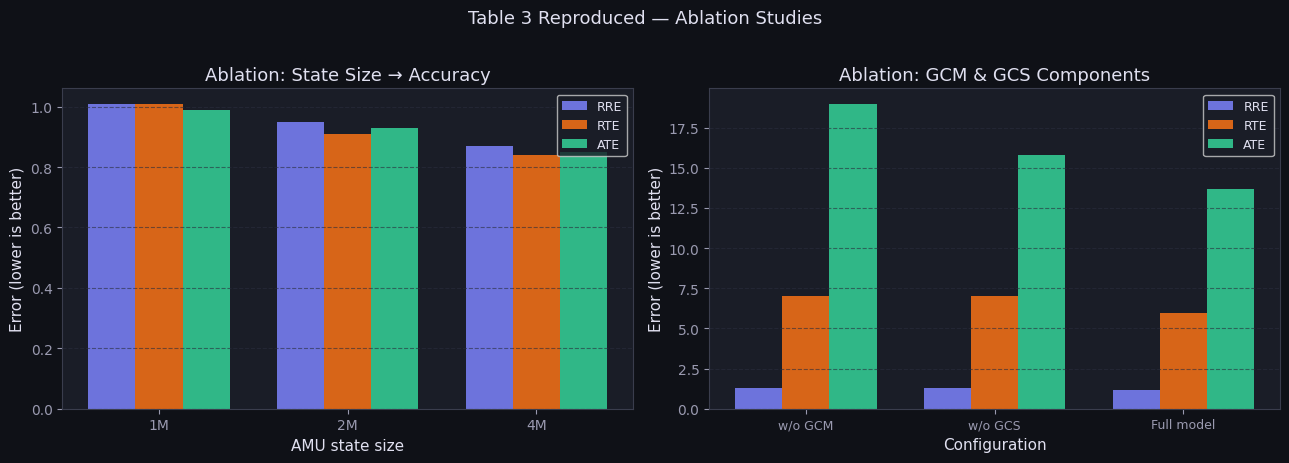

In [13]:
# ─────────────────────────────────────────────────────────────
# SECTION 8 — Ablation studies (Table 3 from paper)
# ─────────────────────────────────────────────────────────────

ablation = {
    'State':  ['1M',  '2M',  '4M'],
    'RRE':    [1.01,  0.95,  0.87],
    'RTE':    [1.01,  0.91,  0.84],
    'ATE':    [0.99,  0.93,  0.85],
}

gcs_abl = {
    'Variant': ['w/o GCM', 'w/o GCS', 'Full model'],
    'RRE':     [1.30,       1.28,       1.17],
    'RTE':     [7.03,       7.01,       5.99],
    'ATE':     [19.00,      15.80,      13.70],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(3)
w = 0.25

for i, (metric, col) in enumerate(zip(['RRE', 'RTE', 'ATE'],
                                       [ACCENT, ACCENT2, ACCENT3])):
    axes[0].bar(x + i * w, ablation[metric], width=w,
                label=metric, color=col, alpha=0.85)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels(ablation['State'])
axes[0].set_xlabel('AMU state size')
axes[0].set_ylabel('Error (lower is better)')
axes[0].set_title('Ablation: State Size → Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(True, axis='y')

for i, (metric, col) in enumerate(zip(['RRE', 'RTE', 'ATE'],
                                       [ACCENT, ACCENT2, ACCENT3])):
    axes[1].bar(x + i * w, gcs_abl[metric], width=w,
                label=metric, color=col, alpha=0.85)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(gcs_abl['Variant'], fontsize=9)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Error (lower is better)')
axes[1].set_title('Ablation: GCM & GCS Components')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y')

plt.suptitle('Table 3 Reproduced — Ablation Studies', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

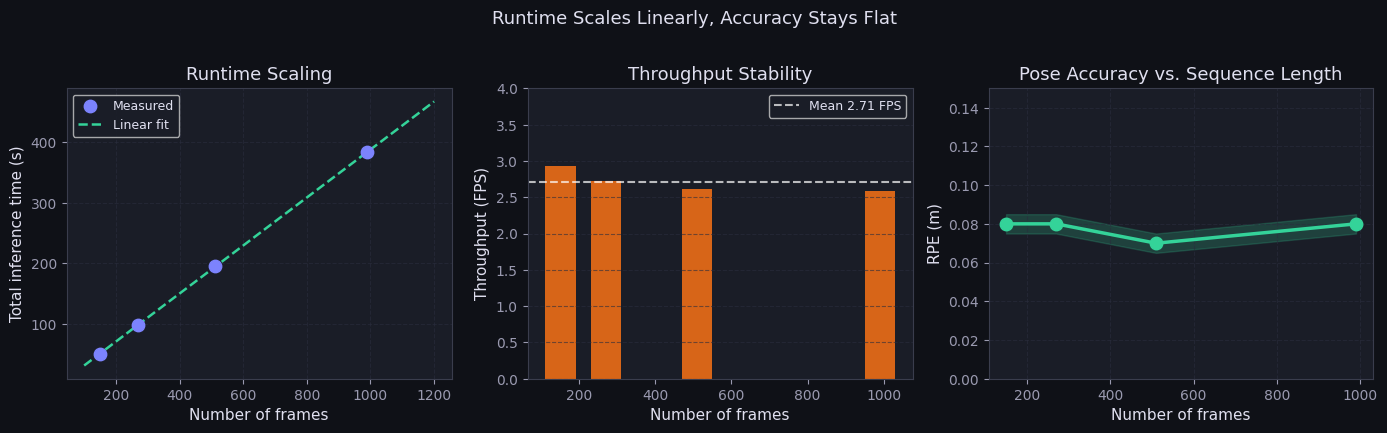

Linear fit: 0.3948 s/frame   R² = 1.0000


In [14]:
# ─────────────────────────────────────────────────────────────
# SECTION 9 — Runtime scaling (Supplementary Table 5)
# ─────────────────────────────────────────────────────────────

frames  = np.array([150, 270, 510, 990])
times   = np.array([51.19, 98.81, 195.24, 382.80])
fps_arr = np.array([2.93, 2.73, 2.61, 2.59])
rpe_arr = np.array([0.08, 0.08, 0.07, 0.08])

x_fit      = np.linspace(100, 1200, 300)
lin_coeffs = np.polyfit(frames, times, 1)
lin_fit    = np.polyval(lin_coeffs, x_fit)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

ax = axes[0]
ax.scatter(frames, times, color=ACCENT, s=80, zorder=5, label='Measured')
ax.plot(x_fit, lin_fit, '--', color=ACCENT3, lw=1.8, label='Linear fit')
ax.set_xlabel('Number of frames')
ax.set_ylabel('Total inference time (s)')
ax.set_title('Runtime Scaling')
ax.legend(fontsize=9)
ax.grid(True)

ax = axes[1]
ax.bar(frames, fps_arr, width=80, color=ACCENT2, alpha=0.85)
ax.axhline(fps_arr.mean(), color='white', lw=1.5, ls='--', alpha=0.7,
           label=f'Mean {fps_arr.mean():.2f} FPS')
ax.set_ylim(0, 4)
ax.set_xlabel('Number of frames')
ax.set_ylabel('Throughput (FPS)')
ax.set_title('Throughput Stability')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

ax = axes[2]
ax.plot(frames, rpe_arr, 'o-', color=ACCENT3, lw=2.5, ms=9)
ax.fill_between(frames, rpe_arr - 0.005, rpe_arr + 0.005,
                alpha=0.2, color=ACCENT3)
ax.set_ylim(0, 0.15)
ax.set_xlabel('Number of frames')
ax.set_ylabel('RPE (m)')
ax.set_title('Pose Accuracy vs. Sequence Length')
ax.grid(True)

plt.suptitle('Runtime Scales Linearly, Accuracy Stays Flat', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

coeff = np.polyfit(frames, times, 1)
r2    = np.corrcoef(frames, times)[0, 1] ** 2
print(f'Linear fit: {coeff[0]:.4f} s/frame   R² = {r2:.4f}')

In [ ]:
# ─────────────────────────────────────────────────────────────
# SECTION 10 — End-to-end pipeline sketch
# ─────────────────────────────────────────────────────────────

class Scal3RPipeline(nn.Module):
    def __init__(self, dim=64, chunk_size=20, overlap=10):
        super().__init__()
        self.chunk_size = chunk_size
        self.overlap    = overlap

        self.encoder = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim)
        )
        self.gcm_modules = nn.ModuleList([
            GlobalContextMemory(dim, n_heads=1, scale=4, inner_lr=1e-3)
            for _ in range(2)
        ])
        self.pose_head  = nn.Linear(dim, 9)
        self.depth_head = nn.Linear(dim, 1)

    def forward(self, frames):
        N      = len(frames)
        chunks = make_chunks(N, self.chunk_size, self.overlap)

        all_poses  = torch.zeros(N, 9)
        all_depths = torch.zeros(N, 1)
        counts     = torch.zeros(N, 1)

        for start, end in chunks:
            X = self.encoder(frames[start:end])
            for gcm in self.gcm_modules:
                X = gcm(X.detach())     # detach between GCM calls
            with torch.no_grad():
                poses  = self.pose_head(X)
                depths = self.depth_head(X)
            all_poses[start:end]  += poses
            all_depths[start:end] += depths
            counts[start:end]     += 1

        return all_poses / counts, all_depths / counts


dim    = 64
N      = 120
model  = Scal3RPipeline(dim=dim, chunk_size=20, overlap=10)
frames = torch.randn(N, dim)

with torch.no_grad():
    poses, depths = model(frames)

print(f'Input:  {frames.shape}')
print(f'Poses:  {poses.shape}   (N × 9 camera parameters)')
print(f'Depths: {depths.shape}  (N × 1 depth scalars)')

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].imshow(poses.numpy().T, aspect='auto', cmap='coolwarm',
               interpolation='nearest')
axes[0].set_xlabel('Frame index')
axes[0].set_ylabel('Pose parameter index')
axes[0].set_title('Predicted Camera Parameters per Frame')

axes[1].plot(depths.numpy(), color=ACCENT3, lw=1.5)
axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('Depth scalar')
axes[1].set_title('Predicted Depth per Frame')
axes[1].grid(True)

plt.tight_layout()
plt.show()
print('All done ✓')